# Which merchants should the BNPL firm onboard?

**Summary of findings** · MAST30034 Applied Data Science, Project 2 (Buy Now, Pay Later)

A Buy Now, Pay Later (BNPL) firm can onboard at most 100 new merchants a year. We ranked all 4,026 merchants that want
to partner with it using 20 months of their transactions (28 Feb 2021 to 26 Oct 2022), consumer details, fraud
probabilities and ABS census-area data. This notebook explains which 100 we recommend and why.

It is written for non-technical readers. It only reads the results of the analysis notebooks, so it runs in seconds.
The code cells are collapsed (click the "..." to expand one) and can be skipped: every finding is stated in the text.

In [1]:
import re
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
from IPython.display import Image, Markdown, display
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

Settings and helper functions used throughout this notebook: file paths, key dates, chart colours and formatting.

In [2]:
# Files
EXTERNAL = Path("external_data")       # ABS data
CURATED = Path("curated")              # files the notebooks pass to each other
OUTPUT = Path("output")                # final rankings (CSV)
PLOTS = Path("plots")                  # charts, saved for the presentation
TRANSACTIONS_FRAUD = CURATED / "transactions_fraud.parquet"  # from fraud.ipynb
MERCHANT_DAILY = CURATED / "merchant_daily.parquet"          # from features.ipynb
MODEL_VALIDATION = CURATED / "fraud_model_validation.csv"
FORECAST_VALIDATION = CURATED / "forecast_validation.csv"
SA2_SUMMARY = CURATED / "sa2_summary.parquet"                # from features.ipynb
SA2_SHAPEFILE = EXTERNAL / "shapefile" / "SA2_2021_AUST_GDA2020.shp"

SEGMENT_ORDER = ["Technology & Media", "Home & Garden", "Fashion & Personal Care", "Hobbies, Arts & Gifts",
                 "Outdoor & Auto"]  # the segments defined in features.ipynb, in a fixed order

# Chart colours
SURFACE, INK, INK_SECONDARY, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
BLUE = "#2a78d6"            # the main colour
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]  # light -> dark


def apply_style():
    """Quiet, consistent chart defaults (the same palette as etl.ipynb). Also stops Jupyter reading the dollar
    signs in tables as maths formulas."""
    pd.set_option("display.html.use_mathjax", False)
    pd.set_option("styler.html.mathjax", False)
    plt.rcParams.update({
        "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
        "axes.edgecolor": GRID, "axes.labelcolor": INK_SECONDARY, "axes.titlecolor": INK,
        "axes.titlesize": 11, "axes.titlelocation": "left", "axes.labelsize": 10,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.grid": True, "grid.color": GRID, "grid.linewidth": 1, "axes.axisbelow": True,
        "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_SECONDARY, "ytick.labelcolor": INK_SECONDARY,
        "legend.frameon": False, "legend.labelcolor": INK, "font.size": 10,
        "lines.linewidth": 2, "lines.solid_capstyle": "round",
    })


def money(x, _=None):
    """$950, $12K, $3.4M (also works as an axis tick formatter)."""
    sign, x = ("-" if x < 0 else ""), abs(x)
    if x >= 1e6:
        return f"{sign}${x / 1e6:,.1f}M".replace(".0M", "M")
    if x >= 1e3:
        return f"{sign}${x / 1e3:,.0f}K"
    return f"{sign}${x:,.0f}"


def show_markdown(text):
    """Display Markdown text. Jupyter reads anything between two dollar signs ("$5 ... $10") as a maths formula, so
    each dollar sign is escaped and wrapped in its own <span> (the markdown cells do the same)."""
    text = re.sub(r"\$(\d(?:[\d,]*\d)?(?:\.\d+)?[KMB]?)", r"<span>\\$\1</span>", text)
    text = re.sub(r"(?<!\\)\$", r"<span>\\$</span>", text)
    display(Markdown(text))


def suptitle(fig, text):
    """A left-aligned title over a figure with several charts."""
    fig.suptitle(text, x=0.01, ha="left", color=INK, fontsize=13)


def save(fig, name):
    """Save a chart to plots/ for the presentation slides."""
    PLOTS.mkdir(exist_ok=True)
    fig.savefig(PLOTS / f"{name}.png", dpi=150, bbox_inches="tight")

In [3]:
apply_style()
pd.set_option("display.max_rows", 120)

ranking = pd.read_csv(OUTPUT / "merchant_ranking.csv")
ranking["category"] = ranking["category_label"]  # short names
top_100 = ranking[ranking["recommendation"] == "top 100"]
robustness = pd.read_csv(OUTPUT / "ranking_robustness.csv", index_col="variant")
model_validation = pd.read_csv(MODEL_VALIDATION, index_col=0)
forecast_validation = pd.read_csv(FORECAST_VALIDATION, index_col=0)


def figure(name, width=900):
    """Show a chart saved by one of the analysis notebooks."""
    display(Image(filename=str(PLOTS / f"{name}.png"), width=width))


profitable = ranking.loc[ranking["expected_profit_12m"] > 0, "expected_profit_12m"].sum()
top_profit = top_100["expected_profit_12m"].sum()
loses_money = (ranking["expected_profit_12m"] <= 0).sum()
big_ticket = ranking[ranking["mean_order"] >= 2000]
modelling = robustness["top 100 unchanged"].iloc[3:]

show_markdown(f"""
## The answer in brief

- **We recommend the 100 merchants in section 5.** Together they are expected to bring the firm about
  **{money(top_profit)} of contribution before operating and credit losses over the next 12 months**. That is {top_profit / profitable:.0%} of the profit available
  from every profitable merchant, from just {100 / len(ranking):.1%} of the merchants.
- **Merchants are ranked by expected profit**: the revenue the firm would earn from them (its take rate on their
  forecast sales) minus the fraud it would expect to lose through them.
- **Good merchants make lots of everyday-value sales.** The top 100 are all large, with a median of
  {top_100['transactions_12m'].median():,.0f} sales a year, and sell everyday items (median merchant-average order
  ${top_100['mean_order'].median():,.0f}): gifts, craft supplies, computers, florists, tents.
- **Big-ticket merchants should be avoided.** Fraud follows the size of the purchase, and a fraudulent sale costs the
  firm the whole amount. **{(big_ticket['expected_profit_12m'] <= 0).mean():.0%} of merchants with an average order
  over $2,000 would lose the firm money**, including jewellers, antique shops, art dealers, telecom and equipment
  rental. In total, {loses_money:,} of the {len(ranking):,} merchants are expected to lose money.
- **Customer demographics and location don't separate merchants.** Large merchants have similar average area-income, gender and state profiles in this synthetic sample.
  These summaries do not establish independence, and individual growth rates vary.
- **The list is robust to our modelling choices** ({modelling.min():.0f}-{modelling.max():.0f} of the 100 stay the
  same when they change), **but it depends on who carries fraud losses**. If merchants rather than the firm bore them,
  about {100 - robustness['top 100 unchanged'].iloc[1]:.0f} of the 100 would change.
""")


## The answer in brief

- **We recommend the 100 merchants in section 5.** Together they are expected to bring the firm about
  **<span>\$20.9M</span> of contribution before operating and credit losses over the next 12 months**. That is 37% of the profit available
  from every profitable merchant, from just 2.5% of the merchants.
- **Merchants are ranked by expected profit**: the revenue the firm would earn from them (its take rate on their
  forecast sales) minus the fraud it would expect to lose through them.
- **Good merchants make lots of everyday-value sales.** The top 100 are all large, with a median of
  16,266 sales a year, and sell everyday items (median merchant-average order
  <span>\$249</span>): gifts, craft supplies, computers, florists, tents.
- **Big-ticket merchants should be avoided.** Fraud follows the size of the purchase, and a fraudulent sale costs the
  firm the whole amount. **99% of merchants with an average order
  over <span>\$2,000</span> would lose the firm money**, including jewellers, antique shops, art dealers, telecom and equipment
  rental. In total, 749 of the 4,026 merchants are expected to lose money.
- **Customer demographics and location don't separate merchants.** Large merchants have similar average area-income, gender and state profiles in this synthetic sample.
  These summaries do not establish independence, and individual growth rates vary.
- **The list is robust to our modelling choices** (97-100 of the 100 stay the
  same when they change), **but it depends on who carries fraud losses**. If merchants rather than the firm bore them,
  about 16 of the 100 would change.


## 1. The data and the pipeline

| Data | Rows | Used for |
|---|---|---|
| Transactions (3 snapshots, 28 Feb 2021 to 26 Oct 2022) | 14.2 million | sales, customers and order values for each merchant |
| Merchants | 4,026 | name, category, revenue level and take rate |
| Consumers | 499,999 (24,081 of them make purchases) | postcode, state and gender of each customer |
| Consumer and merchant fraud probabilities | 34,765 and 114 | how likely transactions are to be fraudulent |
| ABS: SA2 boundaries, population, income, and mesh-block allocation files | 2,473 boundary records; 2,454 population SA2s | where customers live, and local income and population |

The analysis runs as a pipeline of notebooks, each reading the previous one's output, so they run in this order:

| Step | Notebook | What it does |
|---|---|---|
| 1 | `etl.ipynb` | cleans and joins all the data: one row per transaction |
| 2 | `fraud.ipynb` | gives every transaction a fraud probability, using a model where the fraud files stop |
| 3 | `features.ipynb` | describes every merchant with 40 features (size, customers, order value, fraud, growth, demographics) |
| 4 | `forecast.ipynb` | forecasts every merchant's sales and fraud for the next 12 months |
| 5 | `ranking.ipynb` | ranks the merchants, applies business rules, and builds the segments and robustness checks |
| 6 | `summary.ipynb` | this notebook |

### Cleaning decisions (`etl.ipynb`)

| Step | Transactions |
|---|---|
| Raw transactions | 14,195,505 |
| Removed: merchant not in the merchant table (396 ABNs, 4.1% of transactions), so it can't be ranked | -580,830 |
| Removed: amounts below one cent (invalid) | -1,014 |
| Removed: extreme for their own merchant (outside Q1 - 3 x IQR to Q3 + 3 x IQR of that merchant's amounts) | -63,786 |
| **Clean transactions** | **13,549,875** |

- **Postcodes had lost their leading zero** (0862 stored as 862), so every NT and many ACT consumers would have
  missed their ABS data. Padding them back fixed 134,001 transactions.
- **16% of transactions come from consumers with PO-box postcodes**, which have no ABS area. Income was filled with state-level income, and population with the state's **median SA2 population**,
  rather than its total population. Missing geography remains missing and is flagged.
- **Outliers were judged against each merchant's own sales**, not one global cut-off. A <span>\$3,000</span> sale is normal for a
  jeweller but extreme for a florist.

## 2. Fraud risk follows purchase size

The supplied files score consumer-days and merchant-days; they do not record confirmed repayment outcomes.
Risk generally rises with spending. The files stop on 27 Feb 2022, and flagging also changes at the
28 Aug 2021 snapshot boundary.

A two-part model learns supplied flags and probabilities from Aug-Dec, holding out January-February. Usual
spending is fitted only on training data, and valid unusual purchases are retained in behavioural features,
avoiding leakage from full-period outlier filtering. It is then refitted on the six labelled months to estimate
later consumer risk. Agreement with these scores does not prove actual loss accuracy.

`in_fraud_delta` preserves supplied flags separately from the 50% high-risk threshold (`is_fraud`). Within coverage,
unlisted days use zero as a modelling proxy, not a verified genuine label.


,baseline (spend bucket average),model
"finds flagged days: ROC AUC (1 = perfect, 0.5 = guessing)",0.950,0.950
finds flagged days: average precision,0.786,0.856
probability of flagged days: mean absolute error (points),2.907,2.095
expected fraud $ predicted / supplied scores,0.934,1.003


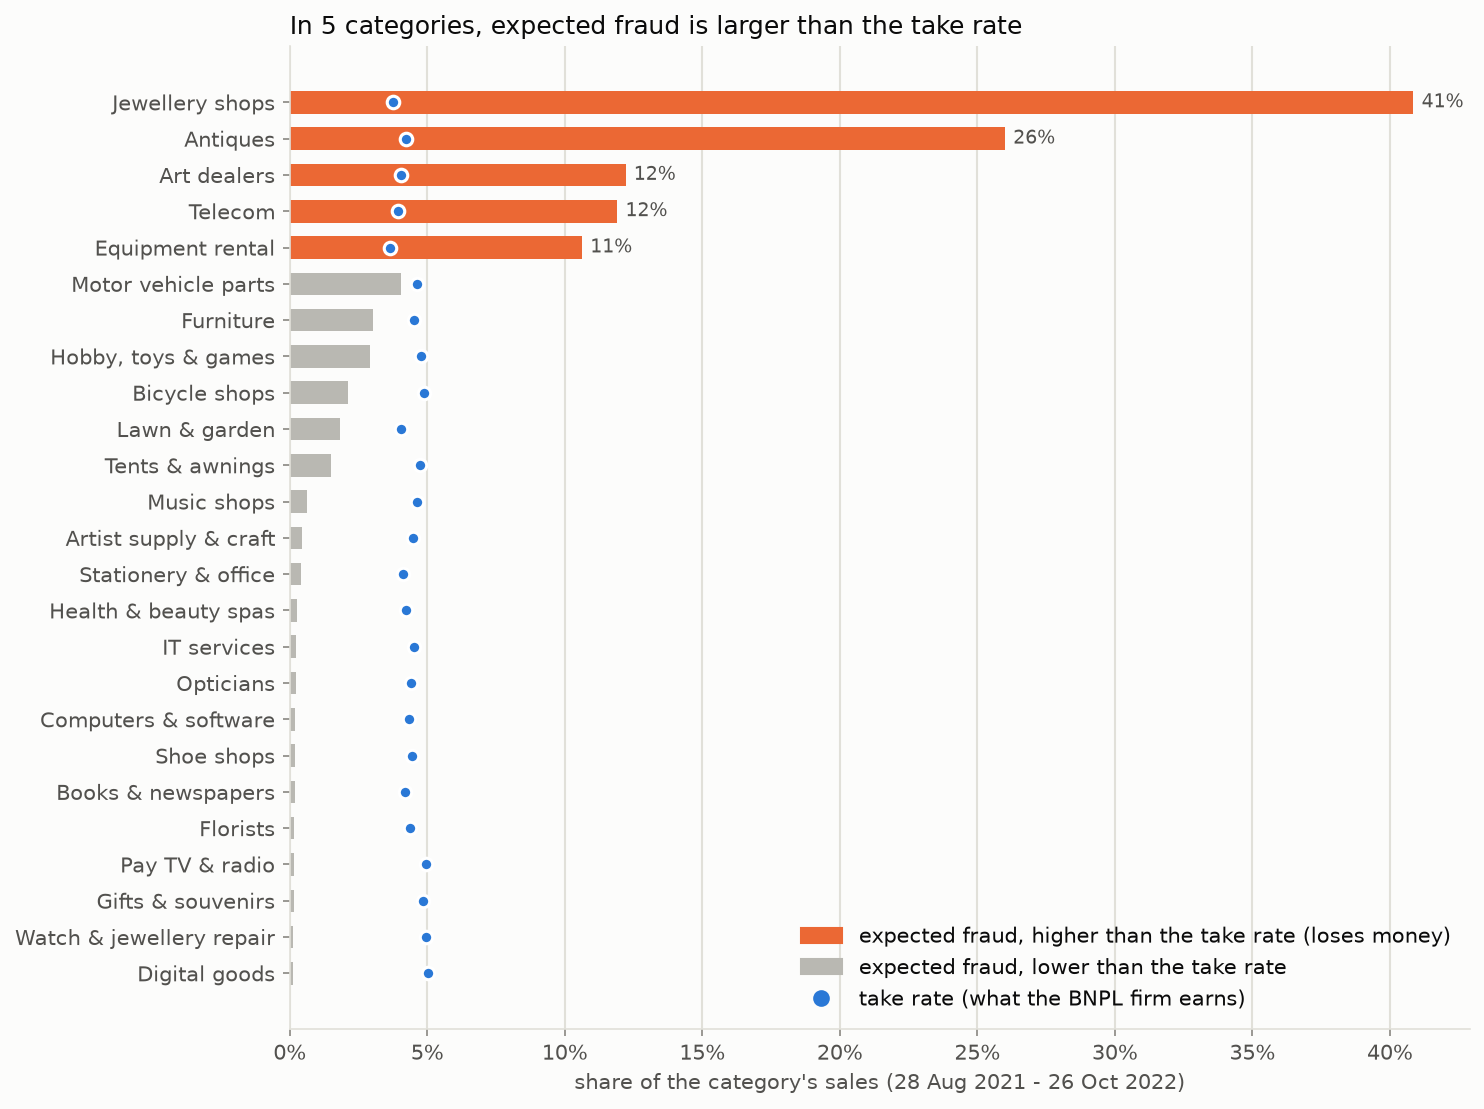

In [4]:
display(model_validation.round(3))
figure("fraud_vs_take_rate_by_category", width=760)

## 3. How the merchants are ranked

**Expected contribution = forecast sales x (take rate - expected fraud rate)**, assuming the firm bears fraud
losses. This excludes operating, funding, onboarding and credit losses; the CSV field `expected_profit_12m` keeps
its existing name.

- **Forecast sales:** last-year sales grown at the observed market rate. Five methods are compared on a
  chronological six-month validation split, with cleaning thresholds fitted only before the cutoff. This is
  method selection on one split, not an independent final test.
- **Take rate:** the supplied merchant fee percentage.
- **Fraud rate:** estimated exposure since 28 Aug 2021, blended with the category when supported by validation.
  The blend is selected against held-out Jan-Feb supplied scores, not later model-generated estimates.

A florist selling $1M at a 5% take rate with 0.15% fraud exposure contributes about $48,500 before other costs.
With 30% exposure, the same sales instead contribute about -$250,000.

**Business rules:** positive contribution, a purchase within 90 days, and no merchant-day score of 50% or more.
Volume/history tiers describe available evidence; they are not statistical confidence levels.


In [5]:
display(forecast_validation.round(3))
funnel = ranking["not_recommended_because"].fillna("").str.split(", ").explode().value_counts().drop("", errors="ignore")
show_markdown(f"""
| | merchants |
|---|---|
| All merchants | {len(ranking):,} |
| Expected to lose money | {funnel.get('loses money', 0):,} |
| No sale in the last 90 days | {funnel.get('no sale in 90+ days', 0):,} |
| Flagged by the merchant fraud file (50%+) | {funnel.get('merchant fraud flag', 0):,} |
| **Eligible** (some fail more than one rule) | **{(ranking['recommendation'] != 'not recommended').sum():,}** |
| **Recommended: the top 100 by expected profit** | **100** |
""")

,"error, $-weighted (WAPE)",R² on log revenue,rank correlation (Spearman),actual top 100 found,total forecast / actual
A. last 6 months,0.097,0.960,0.976,98.0,0.928
B. same 6 months last year,0.179,0.947,0.971,99.0,0.834
C. B x market growth,0.058,0.957,0.971,99.0,1.009
D. B x merchant's own growth,0.133,0.875,0.935,97.0,1.035
E. share of the last 12 months,0.049,0.970,0.979,98.0,1.009



| | merchants |
|---|---|
| All merchants | 4,026 |
| Expected to lose money | 749 |
| No sale in the last 90 days | 65 |
| Flagged by the merchant fraud file (50%+) | 16 |
| **Eligible** (some fail more than one rule) | **3,264** |
| **Recommended: the top 100 by expected profit** | **100** |


## 4. What separates merchants that should and shouldn't be accepted

Each dot below is a merchant. It shows what the merchant would earn the firm (across) and how much of that
fraud would take back (up). The top 100 (blue) sit in the bottom-right corner: **the largest expected contributions under the chosen assumptions.**

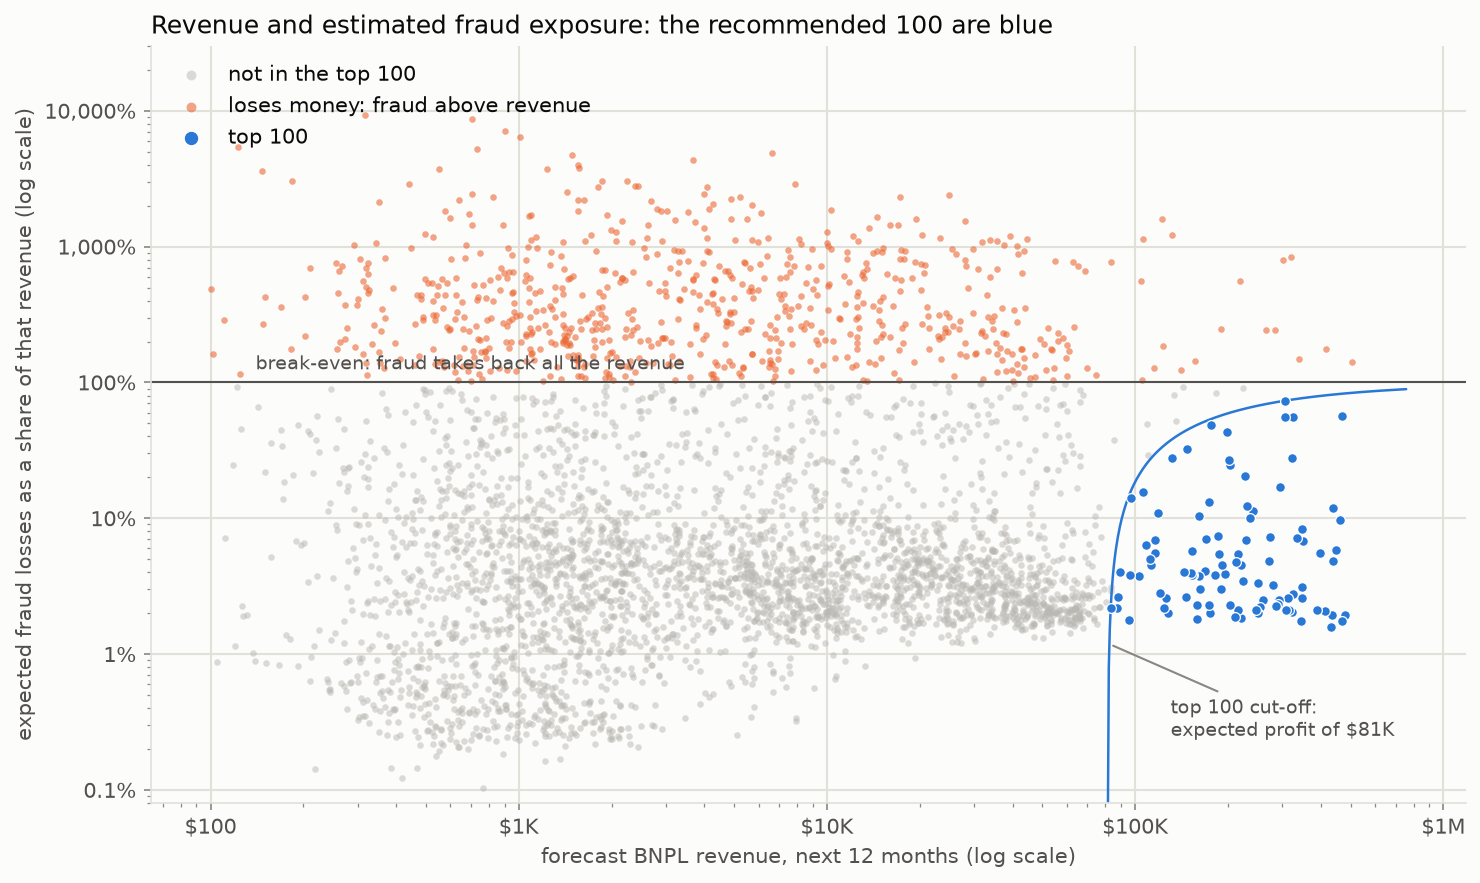

In [6]:
figure("ranking_map", width=880)

In [7]:
groups = {"top 100": ranking["recommendation"] == "top 100",
          "other eligible": ranking["recommendation"] == "eligible",
          "not recommended": ranking["recommendation"] == "not recommended"}
profile = pd.DataFrame({
    name: {
        "merchants": f"{mask.sum():,}",
        "sales in the last 12 months (median)": f"{ranking.loc[mask, 'transactions_12m'].median():,.0f}",
        "average order (median)": f"${ranking.loc[mask, 'mean_order'].median():,.0f}",
        "take rate (median)": f"{ranking.loc[mask, 'take_rate'].median():.1f}%",
        "expected fraud, % of sales (median)": f"{100 * ranking.loc[mask, 'forecast_fraud_rate'].median():.2f}%",
        "expected profit next 12 months (median)": money(ranking.loc[mask, "expected_profit_12m"].median()),
    }
    for name, mask in groups.items()
})
display(profile)

,top 100,other eligible,not recommended
merchants,100,"3,164",762
sales in the last 12 months (median),"16,266",366,24
average order (median),$249,$232,"$2,603"
take rate (median),5.5%,4.7%,3.8%
"expected fraud, % of sales (median)",0.16%,0.14%,11.72%
expected profit next 12 months (median),$183K,$3K,-$7K


**The features and heuristics that separate merchants, in order of importance:**

1. **Size.** Sales volume varies more than a thousand-fold between merchants, far more than anything else. The 100
   largest merchants earn 35% of all BNPL revenue (`features.ipynb`). Every recommended merchant made at least about
   2,200 sales in the last year.
2. **Order value, through fraud.** Big-ticket merchants attract fraud: expected fraud climbs steeply once the
   average order passes about <span>\$1,000</span> (chart below). Revenue-only ranking can include merchants whose expected exposure exceeds their fees; ranking.ipynb
   quantifies the effect.
3. **Take rate.** It is set by the merchant's revenue level (a = highest). Over half the top 100 are level a, and none
   are level d or e. But take rates vary about 20-fold while sales vary over a thousand-fold, so a high take rate
   can't rescue a small or fraud-prone merchant.
4. **What doesn't separate merchants:** customer income, gender, location and growth. Every large merchant's
   customers mirror the whole customer base, and category totals share a similar broad growth trend and seasonal pattern (`features.ipynb`). Repeat customers differ a lot, and are strongly associated with size; this does not prove causation.

**Rule of thumb for screening a new applicant:** a high-volume merchant selling everyday items (orders well under
<span>\$1,000</span>) at a take rate of at least 1.5%. A big-ticket merchant should only be considered with fraud controls that
bring its fraud rate below its take rate.

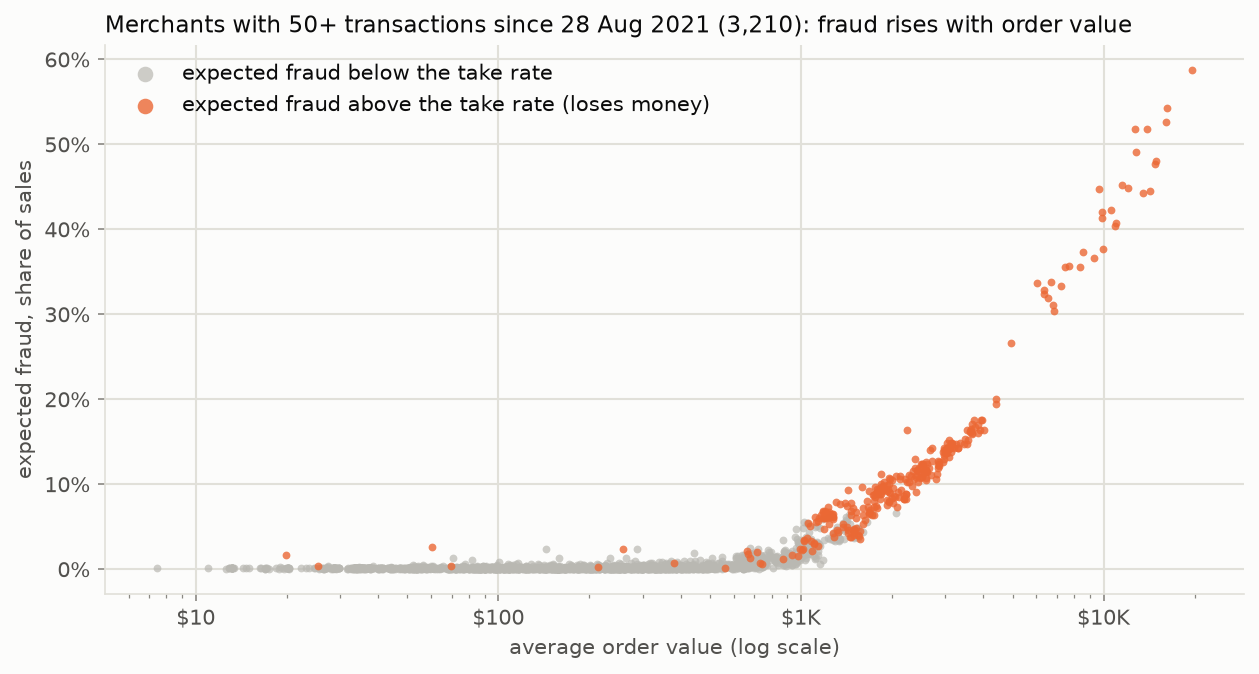

In [8]:
figure("fraud_vs_order_value", width=760)

## 5. The top 100 merchants

In [9]:
TABLE = {"rank": "rank", "merchant_name": "merchant", "merchant_abn": "ABN", "segment": "segment", "category": "category",
         "take_rate": "take rate", "forecast_revenue_12m": "forecast revenue", "forecast_fraud_rate": "expected fraud",
         "expected_profit_12m": "expected profit"}
FORMATS = {"take rate": "{:.2f}%", "forecast revenue": money, "expected fraud": "{:.2%}", "expected profit": money,
           "ABN": "{:d}"}
display(top_100[list(TABLE)].rename(columns=TABLE).set_index("rank").style.format(FORMATS))

,merchant,ABN,segment,category,take rate,forecast revenue,expected fraud,expected profit
rank,,,,,,,,
1,Orci In Consequat Corporation,32361057556,"Hobbies, Arts & Gifts",Gifts & souvenirs,6.61%,$481K,0.13%,$471K
2,Leo In Consulting,86578477987,Fashion & Personal Care,Watch & jewellery repair,6.43%,$469K,0.11%,$461K
3,Lacus Consulting,45629217853,"Hobbies, Arts & Gifts",Gifts & souvenirs,6.98%,$433K,0.11%,$426K
4,Lobortis Ultrices Company,64403598239,"Hobbies, Arts & Gifts",Music shops,6.31%,$434K,0.12%,$426K
5,Ornare Limited,96680767841,Outdoor & Auto,Motor vehicle parts,5.91%,$450K,0.35%,$424K
6,Mauris Non Institute,21439773999,Technology & Media,Pay TV & radio,6.10%,$439K,0.29%,$418K
7,Dignissim Maecenas Foundation,48534649627,Fashion & Personal Care,Opticians,6.64%,$461K,0.65%,$416K
8,Est Nunc Consulting,89726005175,Outdoor & Auto,Tents & awnings,6.01%,$414K,0.12%,$405K
9,Odio Phasellus Institute,63123845164,"Hobbies, Arts & Gifts",Artist supply & craft,6.59%,$439K,0.79%,$387K


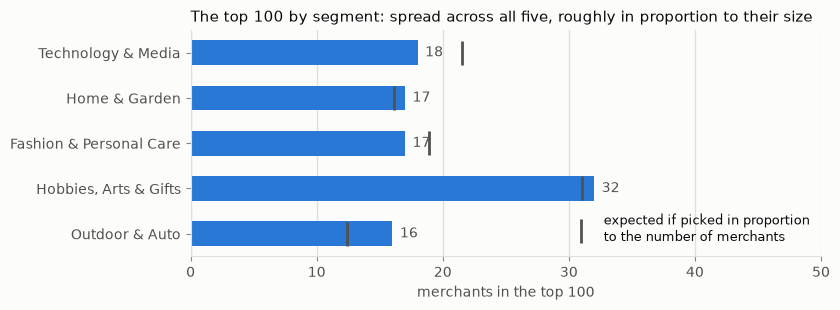


The top 100 come from 21 of the 25 categories, led by
tents & awnings (10), computers & software (8), watch & jewellery repair (7), artist supply & craft (7).
None are jewellery shops, art dealers, telecom or equipment rental. **All 100 are in the high-volume forecast tier** (more
than 1,000 sales in the last year), although model, growth and liability assumptions still affect recommendations.


In [10]:
by_segment = (top_100["segment"].value_counts().reindex(SEGMENT_ORDER).rename("top 100").to_frame()
              .join(ranking["segment"].value_counts().rename("all merchants")))
by_segment["share of all merchants"] = by_segment["all merchants"] / by_segment["all merchants"].sum()

fig, ax = plt.subplots(figsize=(8.5, 3.2))
y = np.arange(len(by_segment))[::-1]
ax.barh(y, by_segment["top 100"], height=0.55, color=BLUE)
ax.scatter(100 * by_segment["share of all merchants"], y, color=INK_SECONDARY, marker="|", s=320, linewidth=2, zorder=3,
           label="expected if picked in proportion\nto the number of merchants")
for yi, count in zip(y, by_segment["top 100"]):
    ax.text(count + 0.6, yi, f"{count}", va="center", color=INK_SECONDARY)
ax.set_yticks(y, by_segment.index)
ax.set_xlabel("merchants in the top 100")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, 50)
ax.legend(loc="lower right", fontsize=9)
ax.set_title("The top 100 by segment: spread across all five, roughly in proportion to their size")
fig.tight_layout()
save(fig, "top_100_by_segment")
plt.show()

top_categories = top_100["category"].value_counts()
show_markdown(f"""
The top 100 come from {top_categories.size} of the 25 categories, led by
{", ".join(f"{name.lower()} ({count})" for name, count in top_categories.head(4).items())}.
None are jewellery shops, art dealers, telecom or equipment rental. **All 100 are in the high-volume forecast tier** (more
than 1,000 sales in the last year), although model, growth and liability assumptions still affect recommendations.
""")

## 6. Top 10 merchants in each segment

The 25 categories are grouped into five segments by what the customer is buying, matching how a BNPL firm would
organise its sales teams. The same score is used in every segment, so a segment's top 10 can be compared directly
with the overall top 100. Segment-specific risk profiles and the justification are documented in ranking.ipynb. Four segments contain a big-ticket category in
which almost every merchant loses money: jewellery shops, art dealers and antiques, equipment rental, and telecom.
There, fraud decides who is excluded, and size decides the order among the rest.

Every segment has at least 15 merchants in the overall top 100, so each segment's top 10 is made up entirely of
recommended merchants (the "overall rank" column shows where each sits in the top 100).

In [11]:
segment_categories = ranking.groupby("segment")["category"].unique().map(lambda c: ", ".join(sorted(c)))
SEGMENT_TABLE = {"segment_rank": "segment rank", "rank": "overall rank", "merchant_name": "merchant", "category": "category",
                 "forecast_revenue_12m": "forecast revenue", "forecast_fraud_rate": "expected fraud",
                 "expected_profit_12m": "expected profit"}
top_10 = ranking[(ranking["recommendation"] != "not recommended") & (ranking["segment_rank"] <= 10)]
for segment in SEGMENT_ORDER:
    rows = top_10[top_10["segment"] == segment]
    show_markdown(f"#### {segment}\n*{segment_categories[segment]}*")
    display(rows[list(SEGMENT_TABLE)].rename(columns=SEGMENT_TABLE).set_index("segment rank").style.format(FORMATS))

#### Technology & Media
*Computers & software, Digital goods, IT services, Pay TV & radio, Telecom*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,6,Mauris Non Institute,Pay TV & radio,$439K,0.29%,$418K
2,13,Nullam Consulting,Digital goods,$345K,0.11%,$339K
3,15,Arcu Sed Eu Incorporated,IT services,$351K,0.33%,$327K
4,17,Adipiscing Elit Foundation,Computers & software,$326K,0.16%,$317K
5,22,Diam At Foundation,IT services,$308K,0.13%,$301K
6,25,Eu Placerat LLC,Computers & software,$287K,0.14%,$280K
7,29,Suspendisse Ac Associates,Digital goods,$260K,0.12%,$253K
8,30,Eleifend PC,IT services,$254K,0.13%,$249K
9,39,Nullam Enim Ltd,Computers & software,$228K,0.22%,$212K


#### Home & Garden
*Equipment rental, Florists, Furniture, Lawn & garden*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,19,Phasellus At Limited,Furniture,$335K,0.33%,$311K
2,21,Lorem Ipsum Sodales Industries,Florists,$312K,0.12%,$304K
3,26,Auctor Company,Florists,$279K,0.15%,$270K
4,31,Purus Gravida Sagittis Ltd,Florists,$250K,0.13%,$245K
5,33,Eu Inc.,Lawn & garden,$247K,0.13%,$241K
6,40,Semper Corp.,Florists,$216K,0.12%,$212K
7,42,Interdum Feugiat Sed Inc.,Furniture,$221K,0.15%,$211K
8,49,Erat Vitae LLP,Florists,$196K,0.11%,$188K
9,53,Phasellus Dapibus Incorporated,Furniture,$187K,0.15%,$177K


#### Fashion & Personal Care
*Health & beauty spas, Jewellery shops, Opticians, Shoe shops, Watch & jewellery repair*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,2,Leo In Consulting,Watch & jewellery repair,$469K,0.11%,$461K
2,7,Dignissim Maecenas Foundation,Opticians,$461K,0.65%,$416K
3,10,Gravida Mauris Incorporated,Watch & jewellery repair,$389K,0.13%,$381K
4,46,Dolor Quisque Inc.,Shoe shops,$231K,0.42%,$203K
5,48,Blandit At LLC,Shoe shops,$204K,0.13%,$199K
6,50,At Pede Inc.,Opticians,$190K,0.19%,$184K
7,56,Sociosqu Corp.,Shoe shops,$175K,0.13%,$172K
8,57,Hendrerit A Corporation,Watch & jewellery repair,$174K,0.15%,$170K
9,61,Nulla Facilisis Institute,Watch & jewellery repair,$158K,0.12%,$155K


#### Hobbies, Arts & Gifts
*Antiques, Art dealers, Artist supply & craft, Books & newspapers, Gifts & souvenirs, Hobby, toys & games, Music shops, Stationery & office*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,1,Orci In Consequat Corporation,Gifts & souvenirs,$481K,0.13%,$471K
2,3,Lacus Consulting,Gifts & souvenirs,$433K,0.11%,$426K
3,4,Lobortis Ultrices Company,Music shops,$434K,0.12%,$426K
4,9,Odio Phasellus Institute,Artist supply & craft,$439K,0.79%,$387K
5,11,Dictum Phasellus In Institute,Gifts & souvenirs,$397K,0.31%,$375K
6,12,Phasellus At Company,Gifts & souvenirs,$348K,0.13%,$339K
7,14,Magna Malesuada Corp.,Artist supply & craft,$348K,0.17%,$337K
8,16,Elit Sed Consequat Associates,Artist supply & craft,$349K,0.49%,$320K
9,20,Ornare Fusce Inc.,"Hobby, toys & games",$315K,0.13%,$309K


#### Outdoor & Auto
*Bicycle shops, Motor vehicle parts, Tents & awnings*

,overall rank,merchant,category,forecast revenue,expected fraud,expected profit
segment rank,,,,,,
1,5,Ornare Limited,Motor vehicle parts,$450K,0.35%,$424K
2,8,Est Nunc Consulting,Tents & awnings,$414K,0.12%,$405K
3,18,Non Vestibulum Industries,Tents & awnings,$323K,0.12%,$317K
4,24,Magna Praesent PC,Motor vehicle parts,$290K,0.16%,$283K
5,32,Luctus Et Incorporated,Tents & awnings,$295K,0.97%,$244K
6,44,Etiam Bibendum Industries,Tents & awnings,$468K,3.56%,$204K
7,47,Suspendisse Non Leo PC,Motor vehicle parts,$212K,0.15%,$202K
8,54,Sit Amet PC,Motor vehicle parts,$181K,0.14%,$174K
9,58,Pede Nonummy Corp.,Tents & awnings,$168K,0.12%,$161K


## 7. Interesting merchants

The spec asks about a few kinds of merchant in particular.

In [12]:
few_big = ranking[(ranking["customers_12m"] < 500) & (ranking["mean_order"] >= 2000)]
many_fraud = ranking[(ranking["customers_12m"] >= 1000) & (ranking["expected_profit_12m"] <= 0)]
new = ranking[ranking["limited_history"]]
watch = top_100[top_100["max_merchant_fraud_probability"].notna()]

# the days the merchant fraud file flagged for the watch-list merchants, against their usual (median) day of sales
flagged_days = (ds.dataset(TRANSACTIONS_FRAUD).to_table(columns=["merchant_abn", "order_datetime"],
                                                        filter=ds.field("merchant_fraud_probability").is_valid())
                .to_pandas().drop_duplicates())
merchant_days = pd.read_parquet(MERCHANT_DAILY, columns=["merchant_abn", "order_datetime", "sales"])
usual_day = merchant_days.groupby("merchant_abn")["sales"].median()
watch_days = flagged_days[flagged_days["merchant_abn"].isin(watch["merchant_abn"])].merge(
    merchant_days, on=["merchant_abn", "order_datetime"])
watch_days["vs_usual"] = watch_days["sales"] / watch_days["merchant_abn"].map(usual_day)
INTERESTING = {"rank": "rank", "merchant_name": "merchant", "category": "category", "customers_12m": "customers",
               "mean_order": "average order", "take_rate": "take rate", "forecast_fraud_rate": "expected fraud",
               "expected_profit_12m": "expected profit"}
STYLE = {**FORMATS, "average order": "${:,.0f}", "customers": "{:,.0f}"}

show_markdown(f"""
### A small customer base that makes large purchases

**{len(few_big):,} merchants** have fewer than 500 customers a year but an average order of $2,000 or more.
They look attractive, with high sales per customer, but **{(few_big['expected_profit_12m'] <= 0).mean():.0%} of them
are expected to lose the firm money**. Large purchases are exactly what the fraud files flag. The five with the most
revenue:
""")
display(few_big.nlargest(5, "forecast_revenue_12m")[list(INTERESTING)].rename(columns=INTERESTING)
        .set_index("rank").style.format(STYLE))

show_markdown(f"""
### A large customer base that is prone to fraud

**{len(many_fraud)} merchants** with 1,000+ customers a year are still expected to lose money. They sell mid-to-high
value items (telecom, art, furniture, garden supplies, motor vehicle parts), where fraud outweighs a normal take rate.
One sells everyday items but has a take rate of just 0.18%, so even its tiny fraud rate wipes out its revenue.
""")
display(many_fraud.sort_values("customers_12m", ascending=False)[list(INTERESTING)].rename(columns=INTERESTING)
        .set_index("rank").style.format(STYLE))

show_markdown(f"""
### New merchants with little information

**{len(new)} merchants** made their first sale less than a year before the data ends, and they have only 1 to
{new['transactions_12m'].max():.0f} sales each. Their forecasts are scaled up to a full year and marked as low
confidence. All of them sell big-ticket items ({", ".join(new['category'].value_counts().index.str.lower())}), and their
few observed purchases have substantial estimated fraud exposure (median expected fraud {new['forecast_fraud_rate'].median():.0%}).
The same eligibility rules apply. Sparse evidence warrants review; first observed sale is not proof that
the business itself is new.

### A watch list inside the top 100

**{len(watch)} of the top 100** appear in the merchant fraud file, each on 1 to 3 days with a probability of about
{watch['max_merchant_fraud_probability'].min():.0%}-{watch['max_merchant_fraud_probability'].max():.0%} (below the 50%
exclusion rule). **All {len(watch_days)} flagged days fall between {watch_days['order_datetime'].min():%d} and
{watch_days['order_datetime'].max():%d %b %Y}**, the Black Friday weekend, when these merchants sold
{watch_days['vs_usual'].min():.1f} to {watch_days['vs_usual'].max():.1f} times their usual daily amount. The timing is consistent with a sales-spike effect, but does not establish that these were false alarms. These merchants stay recommended, but the firm should review
those days before signing them.
""")


### A small customer base that makes large purchases

**481 merchants** have fewer than 500 customers a year but an average order of <span>\$2,000</span> or more.
They look attractive, with high sales per customer, but **99% of them
are expected to lose the firm money**. Large purchases are exactly what the fraud files flag. The five with the most
revenue:


,merchant,category,customers,average order,take rate,expected fraud,expected profit
rank,,,,,,,
4023,Ligula Elit Pretium Foundation,Antiques,112,"$19,627",4.82%,58.77%,-$1.5M
4024,Pharetra Quisque Company,Jewellery shops,374,"$9,900",2.62%,42.05%,-$1.8M
4022,Odio Incorporated,Jewellery shops,117,"$16,046",4.62%,52.66%,-$1.1M
4019,Mi Corporation,Antiques,66,"$13,928",6.77%,51.76%,-$553K
3756,In Scelerisque Inc.,Furniture,380,"$2,229",6.91%,8.80%,-$19K



### A large customer base that is prone to fraud

**13 merchants** with 1,000+ customers a year are still expected to lose money. They sell mid-to-high
value items (telecom, art, furniture, garden supplies, motor vehicle parts), where fraud outweighs a normal take rate.
One sells everyday items but has a take rate of just 0.18%, so even its tiny fraud rate wipes out its revenue.


,merchant,category,customers,average order,take rate,expected fraud,expected profit
rank,,,,,,,
3999,Nec Incorporated,Telecom,"3,122","$1,839",5.55%,9.71%,-$312K
3955,Torquent Per Inc.,Lawn & garden,"2,965","$1,313",2.45%,4.57%,-$106K
3985,Amet Risus Inc.,Furniture,"2,847","$2,017",6.82%,9.58%,-$204K
3978,Magna Sed Industries,Art dealers,"2,470","$1,793",5.96%,8.86%,-$165K
3924,Ac Urna Consulting,Art dealers,"2,458","$1,194",4.25%,6.14%,-$70K
3822,Nam Ligula Elit Foundation,Lawn & garden,"2,355","$1,324",3.58%,4.39%,-$32K
4014,Semper Auctor PC,Motor vehicle parts,"2,306","$2,132",4.52%,11.01%,-$408K
3324,Felis Limited,Furniture,"2,001",$214,0.18%,0.22%,-$204
4021,Pede Cras Vulputate Ltd,Telecom,"1,510","$3,718",3.15%,17.52%,-$997K



### New merchants with little information

**22 merchants** made their first sale less than a year before the data ends, and they have only 1 to
6 sales each. Their forecasts are scaled up to a full year and marked as low
confidence. All of them sell big-ticket items (antiques, jewellery shops, telecom), and their
few observed purchases have substantial estimated fraud exposure (median expected fraud 43%).
The same eligibility rules apply. Sparse evidence warrants review; first observed sale is not proof that
the business itself is new.

### A watch list inside the top 100

**12 of the top 100** appear in the merchant fraud file, each on 1 to 3 days with a probability of about
29%-33% (below the 50%
exclusion rule). **All 20 flagged days fall between 26 and
29 Nov 2021**, the Black Friday weekend, when these merchants sold
2.6 to 3.2 times their usual daily amount. The timing is consistent with a sales-spike effect, but does not establish that these were false alarms. These merchants stay recommended, but the firm should review
those days before signing them.


## 8. Where the customers are

The maps group consumers by the ABS area (SA3) of their postcode. Consumers with PO-box postcodes (16%) can't be
placed and are left out.

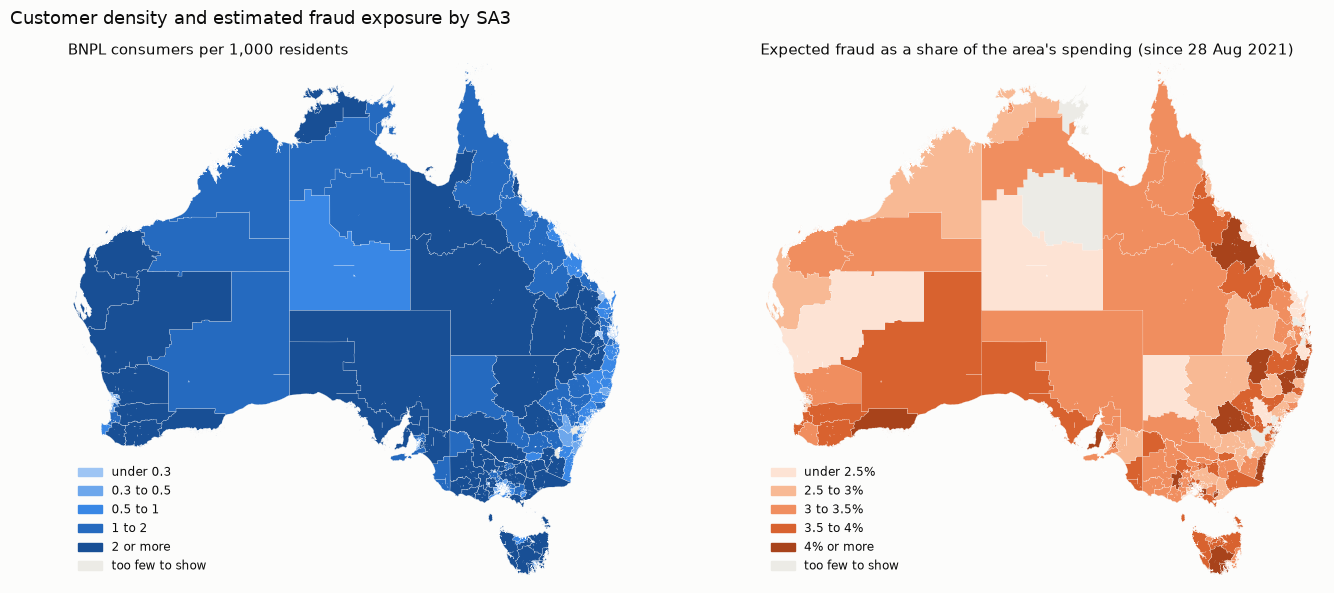

,consumers,population,"consumers per 1,000 residents",expected fraud (% of spending)
region,,,,
capital cities,"7,764","17,991,281",0.43,3.24
rest of Australia,"12,347","8,657,597",1.43,3.36


In [13]:
areas = gpd.read_file(SA2_SHAPEFILE, columns=["SA2_CODE21", "SA3_CODE21", "SA3_NAME21", "GCC_NAME21", "geometry"])
areas = areas[areas.geometry.notna()]
areas["geometry"] = areas.geometry.simplify(0.002, preserve_topology=True)  # lighter outlines, faster to draw
areas = areas.merge(pd.read_parquet(SA2_SUMMARY), left_on="SA2_CODE21", right_on="sa2_code", how="left")
sa3 = areas.dissolve(by="SA3_CODE21", aggfunc={"SA3_NAME21": "first", "GCC_NAME21": "first", "population": "sum",
                                                "consumers": "sum", "sales_since_snapshot": "sum",
                                                "expected_fraud_since_snapshot": "sum"})
sa3["consumers_per_1000"] = 1000 * sa3["consumers"] / sa3["population"].where(sa3["population"] >= 1000)
sa3["fraud_rate"] = sa3["expected_fraud_since_snapshot"] / sa3["sales_since_snapshot"].where(sa3["consumers"] >= 20)


def choropleth(ax, column, bins, labels, colors, title):
    data = sa3[sa3[column].notna()]
    norm = BoundaryNorm(bins, len(colors))
    sa3.plot(ax=ax, color="#ecebe6", linewidth=0)  # areas without enough data
    data.plot(ax=ax, column=column, cmap=ListedColormap(colors), norm=norm, linewidth=0.15, edgecolor="white")
    ax.set_xlim(112.5, 154.5)
    ax.set_ylim(-44.2, -9.5)
    ax.set_axis_off()
    ax.set_title(title)
    handles = [Patch(color=c, label=l) for c, l in zip(colors, labels)] + [Patch(color="#ecebe6", label="too few to show")]
    ax.legend(handles=handles, loc="lower left", fontsize=8.5)


fig, (ax_customers, ax_fraud) = plt.subplots(1, 2, figsize=(14, 6))
choropleth(ax_customers, "consumers_per_1000", [0, 0.3, 0.5, 1, 2, 100],
           ["under 0.3", "0.3 to 0.5", "0.5 to 1", "1 to 2", "2 or more"], BLUE_RAMP[1::1][:5],
           "BNPL consumers per 1,000 residents")
choropleth(ax_fraud, "fraud_rate", [0, 0.025, 0.03, 0.035, 0.04, 1],
           ["under 2.5%", "2.5 to 3%", "3 to 3.5%", "3.5 to 4%", "4% or more"],
           ["#fde3d4", "#f8b994", "#f08e5f", "#d8622f", "#a8431b"],
           "Expected fraud as a share of the area's spending (since 28 Aug 2021)")
suptitle(fig, "Customer density and estimated fraud exposure by SA3")
fig.tight_layout()
save(fig, "maps")
plt.show()

region = sa3.assign(region=np.where(sa3["GCC_NAME21"].str.startswith(("Greater", "Australian Capital")),
                                     "capital cities", "rest of Australia"))
region = region.groupby("region")[["consumers", "population", "expected_fraud_since_snapshot", "sales_since_snapshot"]].sum()
region["consumers per 1,000 residents"] = 1000 * region["consumers"] / region["population"]
region["expected fraud (% of spending)"] = 100 * region["expected_fraud_since_snapshot"] / region["sales_since_snapshot"]
display(region[["consumers", "population", "consumers per 1,000 residents", "expected fraud (% of spending)"]]
        .style.format({"consumers": "{:,.0f}", "population": "{:,.0f}", "consumers per 1,000 residents": "{:.2f}",
                       "expected fraud (% of spending)": "{:.2f}"}))

- **Coverage differs by area.** These maps describe the synthetic sample, excluding unmatched postcodes.
  The population denominator is from 2023 while transactions are from 2021-22: this is retrospective context,
  not an exact adoption rate for one date.
- **No clear geographic signal was detected by this test.** Observed variation was consistent with random
  reassignment in features.ipynb. This does not prove geographic effects are absent.
- **The geography is approximate.** Each postcode takes the SA2 with the most residential mesh blocks, not the
  most verified residents or homes. ABS postal areas themselves approximate postcodes.
- **Location has not shown additional ranking value here.** Large merchants have similar state profiles.
  Smaller merchants do not necessarily reach all eight states. Merchant locations are not supplied.


## 9. How much to trust the ranking

In [14]:
display(robustness.style.format({"top 100 unchanged": "{:.0f}", "rank correlation with the main ranking": "{:.3f}"}))

,top 100 unchanged,rank correlation with the main ranking
variant,,
the firm loses half a fraudulent sale (λ = 0.5),95,0.951
fraud only costs the take rate (λ = 0),84,0.698
fraud ignored (rank by revenue),83,0.666
fraud rate from the fraud files only (no model),97,0.993
fraud rate including the under-flagged first snapshot,99,0.986
retain valid purchase outliers,98,0.996
past revenue instead of the forecast,100,1.000


The table measures overlap when model, cleaning and liability assumptions change. It does not measure
the probability that a merchant belongs in the true top 100. The untrimmed-purchase scenario checks whether
removing large valid purchases materially changes recommendations. Confirm liability terms before a real decision.


## 10. Assumptions, limitations and issues

**Assumptions**
- Unlisted days use a zero-risk proxy within coverage; absence does not prove non-fraud. Supplied matches
  are preserved in in_fraud_delta. Probability-based scoring and the 50% threshold are modelling choices.
- The firm bears the fraud exposure under the main scenario. The supplied files do not establish liability terms.
- The next 12 months look like the last 12, grown at the observed market rate, with the same take rates and fraud
  behaviour.
- Profit is revenue minus fraud only. The data has nothing on operating costs or on genuine customers who fail to
  repay (credit losses), so neither is included.
- Each postcode takes the SA2 with the most residential mesh blocks. Unmatched postcodes get state income
  and the state's median SA2 population. Unmatched does not prove that every such postcode is a PO box.

**Limitations**
- The data is synthetic. Large merchants have similar aggregate demographic profiles. This does not prove customer choice is
  independent of income or geography and should not be generalised to real customers.
- There are no merchant locations, so "merchant location" could only be studied through where customers live.
- Fraud information stops eight months before the transactions do, and its flagging changed on 28 Aug 2021. Fraud
  after 27 Feb 2022 is a model estimate, and merchant-level fraud can't be estimated for that period (too few
  examples to model).
- Forecasts for small and new merchants are uncertain. They're marked `low` confidence, but none of them are near the
  top 100.

**Issues we ran into**
- The third transaction snapshot is labelled as ending on 28 Aug 2022 but runs to 26 Oct 2022. The extra rows look
  genuine and were kept.
- Merchant tags mixed brackets and capitalisation and contained typos, so they needed careful parsing. Postcodes had
  lost leading zeros. The consumer fraud file had duplicate rows that would have double-counted transactions.
- pandas 3 and PySpark 4.2 don't yet convert text columns between each other reliably, so data moves between them
  through parquet files. Holding millions of consumer-days in memory next to Spark crashed the fraud model, which
  now loads one month at a time.

## Reproducing these results

Follow README.md for the Python environment and data placement, then run `python run_pipeline.py` from the
project root. It executes all six notebooks in fresh kernels, saves successful outputs, and regenerates
`curated/`, `plots/` and `output/`. Spark requires Java 17 or newer.

Validation tables are loaded from generated files. See BNPL_SPRINT_6_AUDIT.md for the remaining checkpoint work.
